# Written text as operational data

Written text is one type of data

### Why people write?

 - To communicate: their thoughts, feelings, urgency, needs, information

### Why people communicate?

1. To express emotions
1. To share information
1. To enable or elicit an action
1....

### We will use written text for the purpose other than 
1. To experience emotion
1. To learn something the author intended us to learn
1. To do what the author intended us to do

### Instead, we will use written text to recognize who wrote it
 - By calculating and comparing word frequencies in written documents
 
See, for example, likely fictional story <https://medium.com/@amuse/how-the-nsa-caught-satoshi-nakamoto-868affcef595>

### Example 1. Dictionaries in python (associative arrays)

Plot the frequency distribution of words on a web page.

In [1]:
import requests, re

# re is a module for regular expressions: to detect various combinations of characters
import operator

# Start from a simple document
r = requests.get('http://eecs.utk.edu')

# What comes back includes headers and other HTTP stuff, get just the body of the response
t = r.text

# obtain words by splitting a string using as separator one or more (+) space/like characters (\s) 
wds = re.split('\\s+',t)

# now populate a dictionary (wf)
wf = {}
for w in wds:
    if w in wf: wf [w] = wf [w] + 1
    else:  wf[w] = 1

# dictionaries can not be sorted, so lets get a sorted *list*
wfs = sorted (wf.items(), key = operator.itemgetter (1), reverse=True)   

# lets just have no more than 15 words 
ml = min(len(wfs),15)
for i in range(1,ml,1):
    print (wfs[i][0]+"\t"+str(wfs[i][1]))

class="menu-item	63
menu-item-type-post_type	61
menu-item-object-page	61
<div	47
</div>	44
and	36
<a	29
-->	26
/>	26
of	25
<link	19
<!--	18
0	18
H.	17


### Example 2

Lots of markup in the output, lets remove it --- 

use BeautifulSoup and nltk modules and practice some regular expressions.

In [2]:
import requests, re, nltk
from bs4 import BeautifulSoup
from nltk import clean_html
from collections import Counter
import operator

# we may not care about the usage of stop words
stop_words = nltk.corpus.stopwords.words('english') + [
 'ut', '\'re','.', ',', '--', '\'s', '?', ')', '(', ':', '\'',
 '\"', '-', '}', '{', '&', '|', u'\u2014' ]

# We most likely would like to remove html markup
def cleanHtml (html):
    from bs4 import BeautifulSoup
    soup = BeautifulSoup(html, 'html.parser')
    return soup.get_text()

# We also want to remove special characters, quotes, etc. from each word
def cleanWord (w):
    # r in r'[.,"\']' tells to treat \ as a regular character 
    # but we need to escape ' with \'
    # any character between the brackets [] is to be removed 
    wn = re.sub('[,"\\.\'&\\|:@>*;/=]', "", w)
    # get rid of numbers
    return re.sub('^[0-9\\.]*$', "", wn)
       
# define a function to get text/clean/calculate frequency
def get_wf (URL):
    # first get the web page
    r = requests.get(URL)
    
    # Now clean
    # remove html markup
    t = cleanHtml (r.text).lower()
    
    # split string into an array of words using any sequence of spaces "\s+" 
    wds = re.split('\\s+',t)
    
    # remove periods, commas, etc stuck to the edges of words
    for i in range(len(wds)):
        wds [i] = cleanWord (wds [i])
    
    # If satisfied with results, lets go to the next step: calculate frequencies
    # We can write a loop to create a dictionary, but 
    # there is a special function for everything in python
    # in particular for counting frequencies (like function table() in R)
    wf = Counter (wds)
    
    # Remove stop words from the dictionary wf
    for k in stop_words:
        wf. pop(k, None)
        
    #how many regular words in the document?
    tw = 0
    for w in wf:
       tw += wf[w] 
        
    
    # Get ordered list
    wfs = sorted (wf.items(), key = operator.itemgetter(1), reverse=True)
    ml = min(len(wfs),15)

    #Reverse the list because barh plots items from the bottom
    return (wfs [ 0:ml ] [::-1], tw)
        
# Now populate two lists    
(wf_ee, tw_ee) = get_wf('http://www.gutenberg.org/ebooks/1342.txt.utf-8')
(wf_bu, tw_bu) = get_wf('http://www.gutenberg.org/ebooks/76.txt.utf-8')

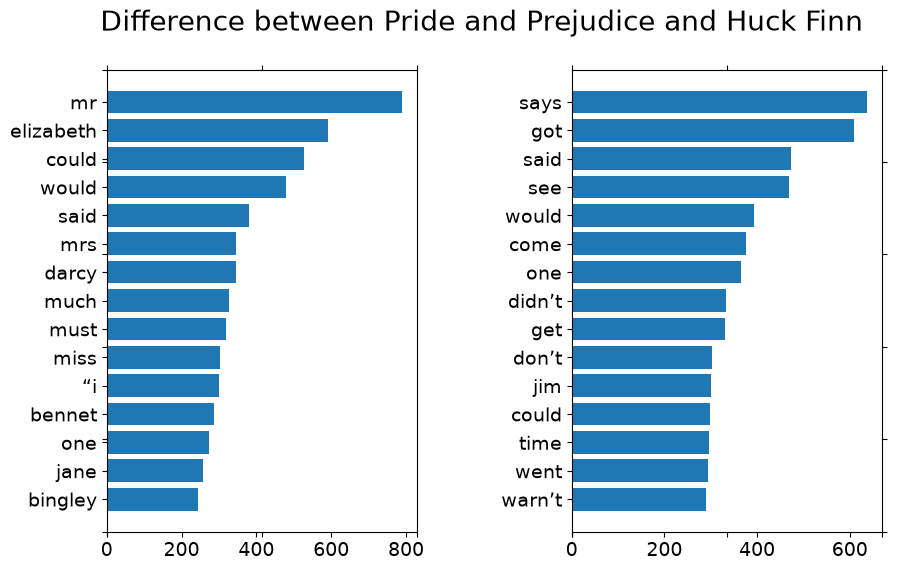

In [3]:
# Plot the results: are there striking differences in language?
import numpy as np
import pylab
import matplotlib.pyplot as plt

%matplotlib inline
def plotTwoLists (wf_ee, wf_bu, title):
    f = plt.figure (figsize=(10, 6))
    # this is painfully tedious....
    f.suptitle (title, fontsize=20)
    ax = f.add_subplot(111)
    ax.spines ['top'].set_color ('none')
    ax.spines ['bottom'].set_color ('none')
    ax.spines ['left'].set_color ('none')
    ax.spines ['right'].set_color ('none')
    ax.tick_params (labelcolor='w', top='off', bottom='off', left='off', right='off', labelsize=20)

    # Create two subplots, this is the first one
    ax1 = f.add_subplot (121)
    plt.subplots_adjust (wspace=.5)

    # pos = np.arange (len(wf_ee)+1) 
    pos = np.arange(len(wf_ee))
    ax1.tick_params (axis='both', which='major', labelsize=14)
    pylab.yticks (pos, [ x [0] for x in wf_ee ])
    ax1.barh (range(len(wf_ee)), [ x [1] for x in wf_ee ], align='center')

    ax2 = f.add_subplot (122)
    ax2.tick_params (axis='both', which='major', labelsize=14)
    # pos = np.arange (len(wf_bu)+1) 
    pos = np.arange(len(wf_bu))
    pylab.yticks (pos, [ x [0] for x in wf_bu ])
    ax2.barh (range (len(wf_bu)), [ x [1] for x in wf_bu ], align='center')

plotTwoLists (wf_ee, wf_bu, 'Difference between Pride and Prejudice and Huck Finn')

In [4]:
# In case Project gutenberg is blocked you can download text to your laptop and copy to the docker container via scp
# Assuming the file name you copy is pg4680.txt here is how you change the script
# Please note the option errors='replace'
# without it python invariably runs into unicode errors
f = open ('pg4680.txt', 'r', encoding="ascii", errors='replace')
    
# What comes back includes headers and other HTTP stuff, get just the body of the response
t = f.read()

# obtain words by splitting a string using as separator one or more (+) space/like characters (\s) 
wds = re.split('\\s+',t)

# now populate a dictionary (wf)
wf = {}
for w in wds:
    if w in wf: wf [w] = wf [w] + 1
    else:  wf [w] = 1

# dictionaries can not be sorted, so lets get a sorted *list*        
wfs = sorted (wf.items(), key = operator.itemgetter (1), reverse=True)   

# lets just have no more than 15 words 
ml = min(len(wfs),15)
for i in range(1,ml,1):
    print (wfs[i][0]+"\t"+str(wfs[i][1]))  

and	2836
of	2676
to	2646
a	2217
in	1422
his	1205
he	928
that	920
was	823
for	798
with	797
as	672
I	505
you	497


# Assignment 1

1. Compare word frequencies between two works of a single author.
1. Compare word frequencies between works of two authors.
1. Are there some words preferred by one author but used less frequently by another author?

Extra credit

1. The frequency of a specific word, e.g., "would" should follow a binomial distribution (each regular word in a document is a trial and with probability p that word is "would". The estimate for p is N("would")/N(regular word)). Do these binomial distributions for your chosen word differ significantly between books of the same author or between authors? 

Project Gutenberg is a good source of for fiction and non-fiction.

E.g below are two most popular books from Project Gutenberg:
- Pride and Prejudice at http://www.gutenberg.org/ebooks/1342.txt.utf-8
- Adventures of Huckleberry Finn at http://www.gutenberg.org/ebooks/76.txt.utf-8

In [5]:
import requests, re, nltk
# In case your text is not on Project Gutenberg but at some other URL
# http://www.fullbooks.com/Our-World-or-The-Slaveholders-Daughter2.html
# that contains 12 parts
t = ""
for i in range(2,13):
  r = requests.get('http://www.fullbooks.com/Our-World-or-The-Slaveholders-Daughter' + str(i) + '.html')
  t = t + r.text

In [6]:
len(t) # 1323653

1323653

## Goal

For this project, I want to investigate how word usage differs between
science fiction and fantasy literature.

I plan to use multiple public-domain books from Project Gutenberg as my
dataset. I will select several science fiction books and several fantasy
books so that the comparison is based on multiple works from each genre
instead of only one book from each category.

In Assignment 1, I worked with word frequencies and compared the words used
by different authors and books. I want to build on that work by applying the
same type of analysis across two genres.

My main question is:

**How does word usage differ between science fiction and fantasy literature?**

I plan to compare the word frequencies of the selected books and identify
words that appear more often in science fiction and words that appear more
often in fantasy. Since the books will likely have different lengths, I will
also account for the total number of words in each book when making the
comparisons.

Using multiple books from Project Gutenberg should help me determine whether
the differences I find appear across several works rather than being caused
by only one specific book or author.

### 1. Compare word frequencies between two works of a single author (Lewis Carroll)

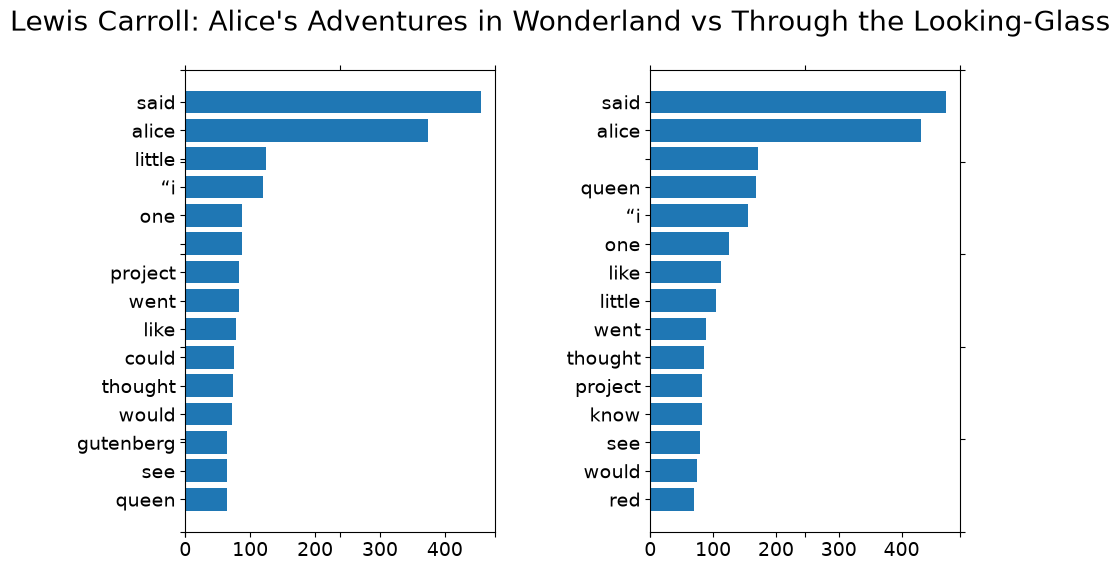

In [7]:
import pandas as pd

# 1. Compare word frequencies between two works of a single author (Lewis Carroll)
wf_alice, tw_alice = get_wf('https://www.gutenberg.org/ebooks/11.txt.utf-8')
wf_looking, tw_looking = get_wf('https://www.gutenberg.org/ebooks/12.txt.utf-8')
plotTwoLists(wf_alice, wf_looking, "Lewis Carroll: Alice's Adventures in Wonderland vs Through the Looking-Glass")

In [8]:
df_alice = pd.DataFrame(wf_alice, columns=['word', 'alice_count'])
df_looking = pd.DataFrame(wf_looking, columns=['word', 'looking_glass_count'])
df_same_author = pd.merge(df_alice, df_looking, on='word', how='outer').fillna(0)
df_same_author['alice_freq'] = (df_same_author['alice_count'] / tw_alice * 10000)
df_same_author['looking_glass_freq'] = (df_same_author['looking_glass_count'] / tw_looking * 10000)
df_same_author

,word,alice_count,looking_glass_count,alice_freq,looking_glass_freq
0,,87.0,172.0,55.105143,94.797178
1,alice,374.0,431.0,236.888776,237.544092
2,could,75.0,0.0,47.504434,0.000000
3,gutenberg,65.0,0.0,41.170509,0.000000
4,know,0.0,82.0,0.000000,45.194004
5,like,78.0,112.0,49.404611,61.728395
6,little,124.0,104.0,78.540664,57.319224
7,one,88.0,125.0,55.738536,68.893298
8,project,83.0,83.0,52.571573,45.745150
9,queen,64.0,169.0,40.537117,93.143739


### 2. Compare word frequencies between works of two authors (Lewis Carroll vs Bram Stoker)

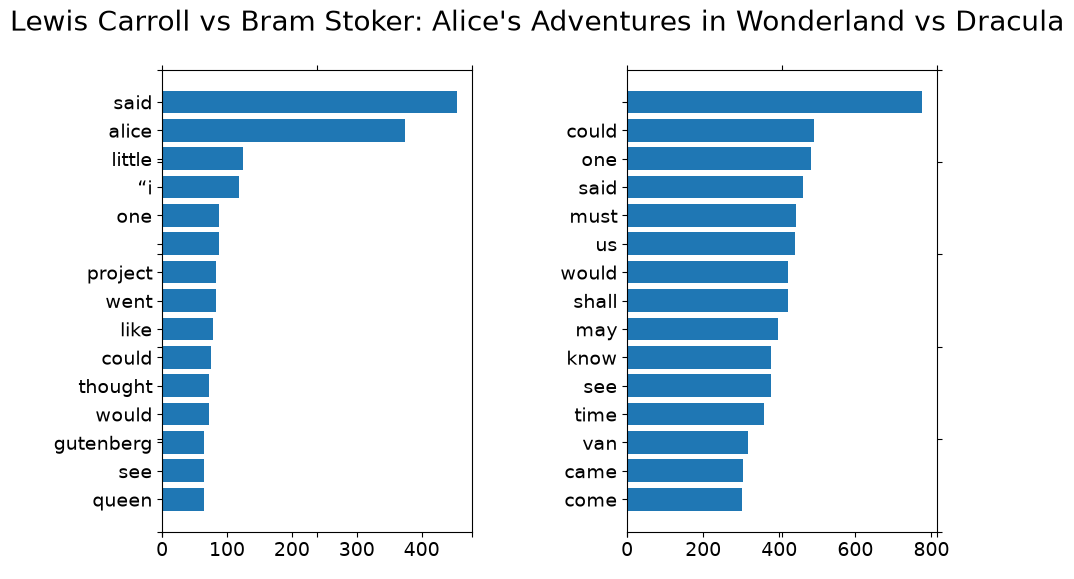

In [9]:
# 2. Compare word frequencies between works of two authors (Lewis Carroll vs Bram Stoker)
wf_dracula, tw_dracula = get_wf('https://www.gutenberg.org/ebooks/345.txt.utf-8')
plotTwoLists(wf_alice, wf_dracula, "Lewis Carroll vs Bram Stoker: Alice's Adventures in Wonderland vs Dracula")

In [10]:
df_dracula = pd.DataFrame(wf_dracula, columns=['word', 'dracula_count'])
df_different_authors = pd.merge(df_alice, df_dracula, on='word', how='outer').fillna(0)
df_different_authors['carroll_freq'] = (df_different_authors['alice_count'] / tw_alice * 10000)
df_different_authors['stoker_freq'] = (df_different_authors['dracula_count'] / tw_dracula * 10000)
df_different_authors

,word,alice_count,dracula_count,carroll_freq,stoker_freq
0,,87.0,776.0,55.105143,102.090487
1,alice,374.0,0.0,236.888776,0.000000
2,came,0.0,305.0,0.000000,40.125771
3,come,0.0,301.0,0.000000,39.599532
4,could,75.0,490.0,47.504434,64.464354
5,gutenberg,65.0,0.0,41.170509,0.000000
6,know,0.0,378.0,0.000000,49.729644
7,like,78.0,0.0,49.404611,0.000000
8,little,124.0,0.0,78.540664,0.000000
9,may,0.0,397.0,0.000000,52.229283


### 3. Find words preferred by one author

In [11]:
# 3. Find words preferred by one author
df_different_authors['difference'] = df_different_authors['carroll_freq'] - df_different_authors['stoker_freq']

df_different_authors['preferred_by'] = (
    df_different_authors['difference'].apply(
        lambda x: 'Lewis Carroll' if x > 0 else 'Bram Stoker'
    )
)

df_different_authors['abs_difference'] = df_different_authors['difference'].abs()
df_different_authors = df_different_authors.sort_values('abs_difference', ascending=False)
df_different_authors[['word', 'carroll_freq', 'stoker_freq', 'preferred_by']].head(15)

,word,carroll_freq,stoker_freq,preferred_by
1,alice,236.888776,0.000000,Lewis Carroll
14,said,288.193565,60.649117,Lewis Carroll
8,little,78.540664,0.000000,Lewis Carroll
23,“i,75.373702,0.000000,Lewis Carroll
10,must,0.000000,58.412598,Bram Stoker
19,us,0.000000,58.017918,Bram Stoker
16,shall,0.000000,55.649840,Bram Stoker
21,went,52.571573,0.000000,Lewis Carroll
12,project,52.571573,0.000000,Lewis Carroll
9,may,0.000000,52.229283,Bram Stoker


### 4. Extra Credit

In [12]:
# Extra Credit
# Compare the binomial distribution of a specific word between books

def get_word_count(URL, word):
    r = requests.get(URL)

    # Clean the text using the existing functions
    t = cleanHtml(r.text).lower()
    wds = re.split('\\s+', t)

    for i in range(len(wds)):
        wds[i] = cleanWord(wds[i])

    wf = Counter(wds)

    # Remove stop words
    for k in stop_words:
        wf.pop(k, None)

    # Number of regular words in the document
    tw = 0
    for w in wf:
        tw += wf[w]

    return wf[word], tw

In [13]:
# Compare "would" between two books by Lewis Carroll

word = 'would'

alice_count, alice_total = get_word_count('https://www.gutenberg.org/ebooks/11.txt.utf-8', word)
looking_count, looking_total = get_word_count('https://www.gutenberg.org/ebooks/12.txt.utf-8', word)

alice_p = alice_count / alice_total
looking_p = looking_count / looking_total

print(f"Alice's Adventures in Wonderland")
print(f"Count: {alice_count}")
print(f"Total words: {alice_total}")
print(f"p: {alice_p}")

print(f"\nThrough the Looking-Glass")
print(f"Count: {looking_count}")
print(f"Total words: {looking_total}")
print(f"p: {looking_p}")

Alice's Adventures in Wonderland
Count: 72
Total words: 15788
p: 0.004560425639726374

Through the Looking-Glass
Count: 75
Total words: 18144
p: 0.004133597883597883


In [14]:
from scipy.stats import norm
import numpy as np

def compare_word_proportions(count1, total1, count2, total2):
    p1 = count1 / total1
    p2 = count2 / total2

    # Pooled probability
    p = (count1 + count2) / (total1 + total2)

    # Standard error
    se = np.sqrt(
        p * (1 - p) * ((1 / total1) + (1 / total2))
    )

    # Z statistic
    z = (p1 - p2) / se

    # Two-sided p-value
    p_value = 2 * (1 - norm.cdf(abs(z)))

    return z, p_value

In [15]:
z, p_value = compare_word_proportions(alice_count, alice_total, looking_count, looking_total)

print(f"z = {z}")
print(f"p-value = {p_value}")

if p_value < 0.05:
    print('The frequency of "would" is significantly different between the two books.')
else:
    print('The frequency of "would" is not significantly different between the two books.')

z = 0.5971271678426585
p-value = 0.5504224806157694
The frequency of "would" is not significantly different between the two books.


In [16]:
# Compare "would" between Lewis Carroll and Bram Stoker

dracula_count, dracula_total = get_word_count('https://www.gutenberg.org/ebooks/345.txt.utf-8', word)
dracula_p = dracula_count / dracula_total

print("Alice's Adventures in Wonderland")
print(f"Count: {alice_count}")
print(f"Total words: {alice_total}")
print(f"p: {alice_p}")

print(f"\nDracula")
print(f"Count: {dracula_count}")
print(f"Total words: {dracula_total}")
print(f"p: {dracula_p}")

Alice's Adventures in Wonderland
Count: 72
Total words: 15788
p: 0.004560425639726374

Dracula
Count: 423
Total words: 76011
p: 0.005564984015471445


In [17]:
z, p_value = compare_word_proportions(alice_count, alice_total, dracula_count, dracula_total)

print(f"z = {z}")
print(f"p-value = {p_value}")

if p_value < 0.05:
    print('The frequency of "would" is significantly different between Carroll and Stoker.')
else:
    print('The frequency of "would" is not significantly different between Carroll and Stoker.')

z = -1.5683696679981352
p-value = 0.11679488562038998
The frequency of "would" is not significantly different between Carroll and Stoker.


In [18]:
extra_credit = pd.DataFrame({
    'book': [
        "Alice's Adventures in Wonderland",
        "Through the Looking-Glass",
        "Dracula"
    ],
    'author': [
        'Lewis Carroll',
        'Lewis Carroll',
        'Bram Stoker'
    ],
    'would_count': [
        alice_count,
        looking_count,
        dracula_count
    ],
    'total_words': [
        alice_total,
        looking_total,
        dracula_total
    ]
})

extra_credit['p_would'] = (
    extra_credit['would_count'] /
    extra_credit['total_words']
)

extra_credit

,book,author,would_count,total_words,p_would
0,Alice's Adventures in Wonderland,Lewis Carroll,72,15788,0.004560
1,Through the Looking-Glass,Lewis Carroll,75,18144,0.004134
2,Dracula,Bram Stoker,423,76011,0.005565
